In [80]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator

from collections import defaultdict

from scipy.ndimage import median_filter
from scipy.signal import savgol_filter

%load_ext line_profiler

import plotparams 
plotparams.default()

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


'Now using the default theme'

In [24]:
# import funcs

%run ./utils.ipynb
%run ./utilsMassProfile.ipynb

In [25]:
Myr_per_Nbody = 0.36627254517014160E+03/ 0.15200000000000000E+03
source = '/cosma5/data/durham/dc-pick2/simulations'
hyades = source + '/Hyades'
hyades

'/cosma5/data/durham/dc-pick2/simulations/Hyades'

In [4]:
path = hyades + '/snap.40_240.h5part'
path

'/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_240.h5part'

In [10]:
with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody

        mtot = np.sum(m)



In [135]:
# step interval is always 0.125 Nbody units

with h5py.File(source + '/Concentration/6' + '/snap.40_80.h5part', 'r') as f:
    step_times = {step: f[step].attrs['Time'] for step in f.keys()}

step_names = sorted(step_times.keys(), key=lambda k: int(k.replace("Step#", "")))
times = np.array([step_times[s] for s in step_names])
np.diff(times)

array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125,
       0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125,
       0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125,
       0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125,
       0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125,
       0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125,
       0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125,
       0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125,
       0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125,
       0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125,
       0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125,
       0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125,
       0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125,
       0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125,
       0.125, 0.125,

array([8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8.,
       8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8.,
       8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8.,
       8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8.,
       8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8.,
       8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8.,
       8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8.,
       8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8.,
       8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8.,
       8., 8., 8., 8., 8., 8.])

In [187]:
get_com(x, y, z, m)

array([15.102393 , -7.5536737,  0.4713251], dtype=float32)

In [11]:
%timeit -n 100 shrinking_sphere(x, y, z, m, r=25, rate=0.8)

695 μs ± 7.17 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [209]:
%timeit -n 100 shrinking_sphere(x, y, z, m, r=25, rate=0.8)

1.31 ms ± 3.49 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [210]:
%timeit -n 100 shrinking_sphere(x, y, z, m, r=10, rate=0.8)

938 μs ± 13.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [211]:
%timeit -n 100 shrinking_sphere(x, y, z, m, r=25, rate=0.7)

1.09 ms ± 2.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [208]:
%timeit -n 100 shrinking_sphere_old(x, y, z, m, r=25, rate=0.8)

1.31 ms ± 6.09 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [15]:
3.86 / 2.88 # speedup

1.3402777777777777

In [28]:
history = []
com = shrinking_sphere(x, y, z, m, history=history, r=25, rate=0.8)

history = np.asarray(history)
history

array([[-1032.8811  ,   536.35803 ,    -9.94536 ],
       [-1032.996   ,   536.5436  ,    -8.953743],
       [-1033.0194  ,   536.4796  ,    -8.971655],
       [-1032.9486  ,   536.4312  ,    -9.023948],
       [-1033.057   ,   536.5188  ,    -8.948132],
       [-1033.1814  ,   536.49194 ,    -9.004207],
       [-1033.1735  ,   536.5777  ,    -9.04395 ],
       [-1033.1216  ,   536.6428  ,    -9.112627],
       [-1033.224   ,   536.6148  ,    -9.03043 ],
       [-1033.0575  ,   536.6425  ,    -9.033571]], dtype=float32)

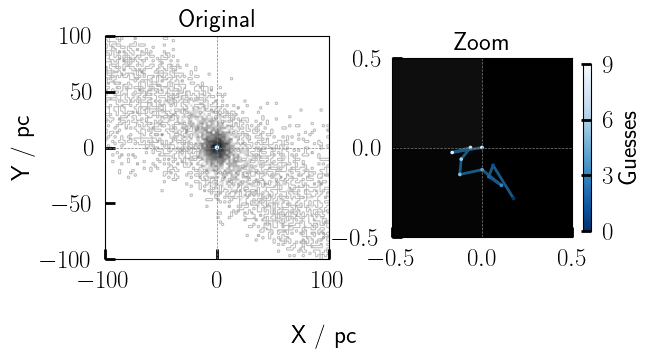

In [86]:
offset = 100
zoom_offset = 0.5

fig, ax = plt.subplots(1,2, figsize=(6,4))

hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, range=[[-offset, offset], [-offset, offset]])
ax[0].imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)
hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, range=[[-offset, offset], [-offset, offset]])
ax[1].imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)


histx = history.T[0]
histy = history.T[1]

ax[0].plot(histx - com[0], histy - com[1], color='tab:blue', alpha=0.75)
ax[1].plot(histx - com[0], histy - com[1], color='tab:blue', alpha=0.75, linewidth=2)

ax[0].scatter(histx - com[0], histy - com[1], label='guesses', marker='.',
                c=range(len(history)), cmap='Blues_r', s=10, zorder=2)
cb = ax[1].scatter(histx - com[0], histy - com[1], label='COM guesses', marker='.',
                c=range(len(history)), cmap='Blues_r', s=10, zorder=2)

cbar = plt.colorbar(cb, ax=ax[1], shrink=0.4, label='Guesses')
cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))


ax[0].set_xlim(-offset, offset)
ax[0].set_ylim(- offset, offset)
ax[0].set_aspect('equal')
ax[0].set_title('Original')


ax[1].set_xlim(-zoom_offset, zoom_offset)
ax[1].set_ylim(- zoom_offset, zoom_offset)
ax[1].set_aspect('equal')
ax[1].set_title('Zoom')

ax[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax[0].axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax[1].axvline(0, color='gray', linewidth=0.5, linestyle='--')

fig.supxlabel('X / pc', fontsize=18)
ax[0].set_ylabel('Y / pc')
plt.tight_layout(pad=-0.5)

#fig.suptitle('Shrinking Shpere Centre of Mass', y=0.85)

plt.savefig('Images/ShrinkShereCOM.png', bbox_inches='tight')
plt.show()

3.85 ms ± 172 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [9]:
fractions = np.asarray([0.75, 0.5, 0.25])
frac_mass_radii = find_bounding_radii(x, y, z, m, fractions)
frac_mass_radii

array([99.99002  , 28.555422 ,  7.4819603], dtype=float32)

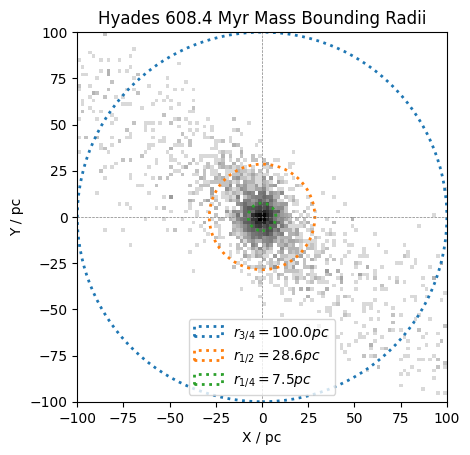

In [10]:
offset = 100
frac_lables = ['3/4', '1/2', '1/4']
lables = [fr'$r_{{{l}}}={v:.1f}pc$' for l, v in zip(frac_lables, frac_mass_radii)]
          
colours = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots()

hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, 
                                      range=[[-offset, offset], [-offset, offset]])
ax.imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)

for r, label, colour in zip(frac_mass_radii, lables, colours):
    r_mass_radius = Circle((0,0), r, fill=False, linestyle='dotted',
                           color=colour, label=label, linewidth=2)
    ax.add_artist(r_mass_radius)



ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title(f'Hyades {t:.1f} Myr Mass Bounding Radii')
ax.set_xlabel('X / pc')
ax.set_ylabel('Y / pc')
ax.set_xlim(-offset, offset)
ax.set_ylim(- offset, offset)
ax.set_aspect('equal')
plt.legend()

plt.show()


In [11]:
fractions = np.asarray([0.75, 0.5, 0.25])
results = []
times = []

for snap in [0, 60, 120, 180, 240]:
    path = hyades + f'/snap.40_{snap}.h5part'

    with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody

        frac_mass_radii = find_bounding_radii(x, y, z, m, fractions)
        results.append(frac_mass_radii)
        times.append(t)

    
results = np.asarray(results)
times = np.asarray(times)




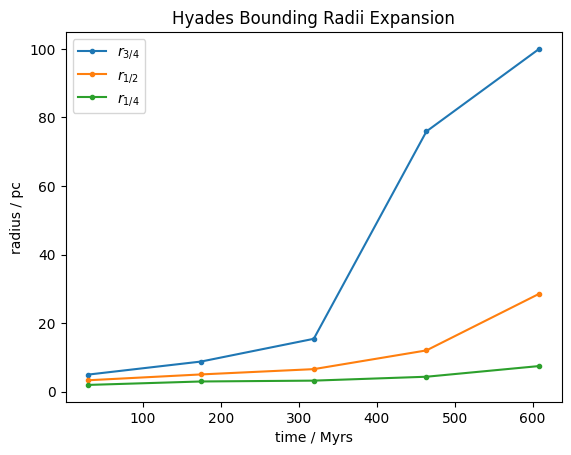

In [12]:
frac_lables = ['3/4', '1/2', '1/4']
lables = [fr'$r_{{{l}}}$' for l in frac_lables]

fig, ax = plt.subplots()

for i, (label, colour) in enumerate(zip(lables, colours)):
    ax.plot(times, results.T[i], label=label, color=colour, marker='.')

ax.set_xlabel('time / Myrs')
ax.set_ylabel('radius / pc')

#ax.set_yscale('log')

plt.title("Hyades Bounding Radii Expansion")
plt.legend()
plt.show()
 

In [13]:
results.T[0]

array([ 4.993082,  8.79833 , 15.429023, 75.92934 , 99.99002 ],
      dtype=float32)

In [63]:
%timeit -n 10 find_mass_profile_old(x, y, z, m)

5.33 ms ± 112 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [78]:
%timeit -n 10 find_mass_profile(x, y, z, m, com=None, bins=25, rmax=10**5)

5.57 ms ± 375 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


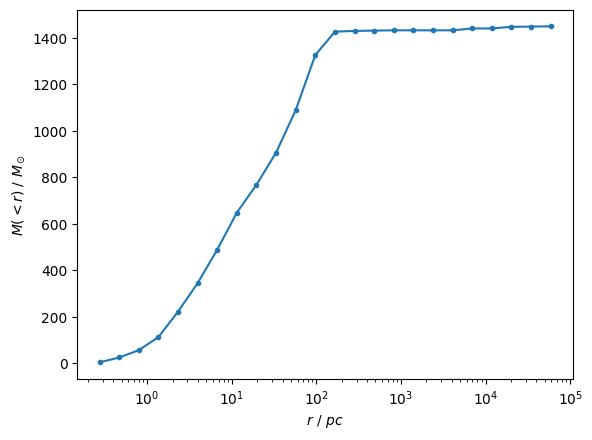

In [80]:
rad_edges, mass_per_bin, cummass = find_mass_profile(x, y, z, m, com=None, bins=25, rmax=10**5)

fig, ax = plt.subplots()

ax.plot(rad_edges, cummass, marker='.')
ax.set_xlabel(r'$r$ / $pc$')
ax.set_ylabel(r'$M(<r)$ / $M_\odot$')

ax.set_xscale('log')

plt.show()

In [176]:
def test():
    times = [0,100,200,300,400,500]
    data, Myr_per_Nbody = get_steps_at_times(hyades, times)
    mass_profiles = find_mass_profiles(data, rmax=10**3)

%lprun -f get_steps_at_times -f shrinking_sphere -f get_Myr_per_Nbody test()

Timer unit: 1e-09 s

Total time: 0.048487 s
File: /tmp/ipykernel_2761841/731330798.py
Function: get_steps_at_times at line 28

Line #      Hits         Time  Per Hit   % Time  Line Contents
    28                                           def get_steps_at_times(path, times, run='', snap_interval=20, step_interval=0.125):
    29         1   13695538.0 1.37e+07     28.2      Myr_per_Nbody = get_Myr_per_Nbody(path)
    30                                           
    31                                               # find the snap and step within that each time would be stored at 
    32         1      13145.0  13145.0      0.0      times = np.asarray(times)
    33         1      19336.0  19336.0      0.0      nbody_times = times / Myr_per_Nbody
    34         1      12263.0  12263.0      0.0      snap_at_time = (nbody_times // snap_interval * snap_interval).astype(int)
    35         1       6122.0   6122.0      0.0      step_at_snap = ((nbody_times - snap_at_time) // step_interval).ast

In [145]:
times = [0,100,200,300,400,500]

data, Myr_per_Nbody = get_steps_at_times(hyades, times)

mass_profiles = find_mass_profiles(data, rmax=10**3)

/tmp/ipykernel_2761841/1385138055.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)


np.float64(500.01021791318675)

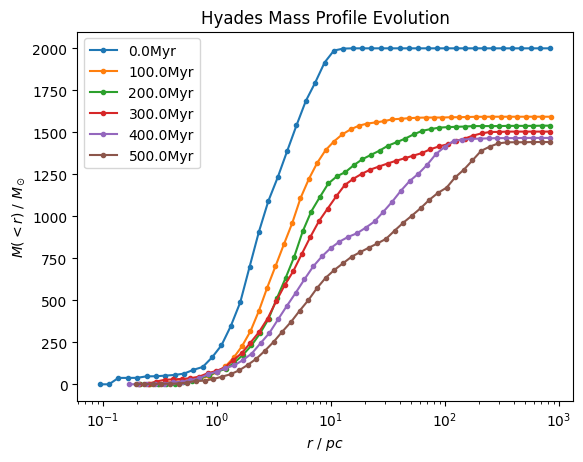

In [94]:
fig, ax = plt.subplots()
plot_mass_profile(fig, ax, mass_profiles, title='Hyades Mass Profile Evolution', marker='.', legend=True)
plt.show()

In [112]:
times = [0, 300, 600]
experiment_path = source + '/Concentration'

runs_data = get_runs_data(experiment_path, times)

runs_mass_profiles = find_mass_profiles_experiment(runs_data, bins=50, rmax=10**3)


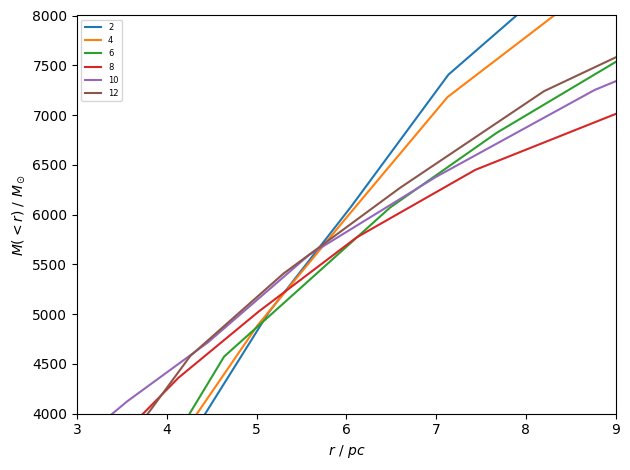

In [89]:

fig, ax = plt.subplots()

#plot_mass_profiles(fig, axes, runs_mass_profiles, titlehead=r'$W_0$ = ')

for run, mass_profiles in runs_mass_profiles.items():
    (r_sort, _, m_sums) = mass_profiles[0]
    ax.plot(r_sort, m_sums, label=run)

ax.set_xlim([3,9])
ax.set_ylim([4000,8000])

ax.set_xlabel(r'$r$ / $pc$')
ax.set_ylabel(r'$M(<r)$ / $M_\odot$')

plt.legend()
ax.legend(fontsize=6)
plt.tight_layout()
plt.show()

In [120]:
intersect_x

array([25.98316866])

/tmp/ipykernel_2101919/2322408145.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


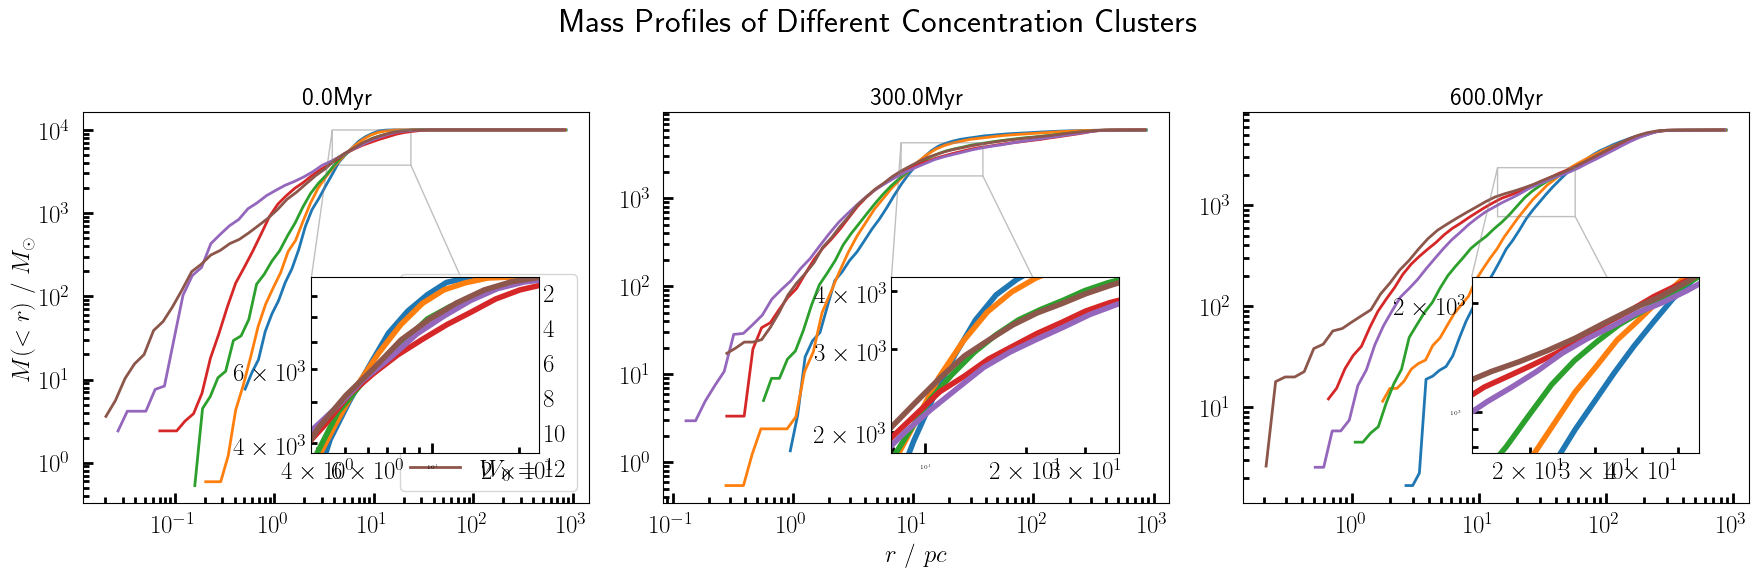

In [97]:
fig, axes = plt.subplots(1, len(times), figsize=(6*len(times),6))

zooms = {ax: inset_axes(ax, width="45%", height="45%", loc="lower right", borderpad=2) for ax in axes}

for run, mass_profiles in runs_mass_profiles.items():
    first = True
    for ax, (time, (r_sort, _, m_sums)) in zip(axes, mass_profiles.items()):
        ax.plot(r_sort, m_sums, label=fr'$W_0={{{run}}}$' if first else '',
               linewidth=2)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f'{time:.1f}Myr')

        first = False

        zoom = zooms[ax]
        zoom.plot(r_sort, m_sums)

for ax, time in zip(axes, times):
    zoom = zooms[ax]
    
    all_x = np.concatenate([runs_mass_profiles[run][time][0] for run in runs_mass_profiles.keys()])
    all_y = np.concatenate([runs_mass_profiles[run][time][2] for run in runs_mass_profiles.keys()])

    x1, x2 = np.percentile(all_x, [40, 60])
    y1, y2 = np.percentile(all_y, [40, 60])

    zoom.set_xscale('log')
    zoom.set_yscale('log')
    zoom.set_xlim(x1, x2)
    zoom.set_ylim(y1, y2)

    zoom.tick_params(labelsize=4)

    ax.indicate_inset_zoom(zoom)
    #ax.tick_params(labelsize=14)


axes[len(times)//2].set_xlabel(r'$r$ / $pc$')
axes[0].set_ylabel(r'$M(<r)$ / $M_\odot$')
axes[0].legend()

plt.suptitle('Mass Profiles of Different Concentration Clusters')
plt.tight_layout()
plt.savefig('Images/W_0_mass_profiles.png')
plt.show()

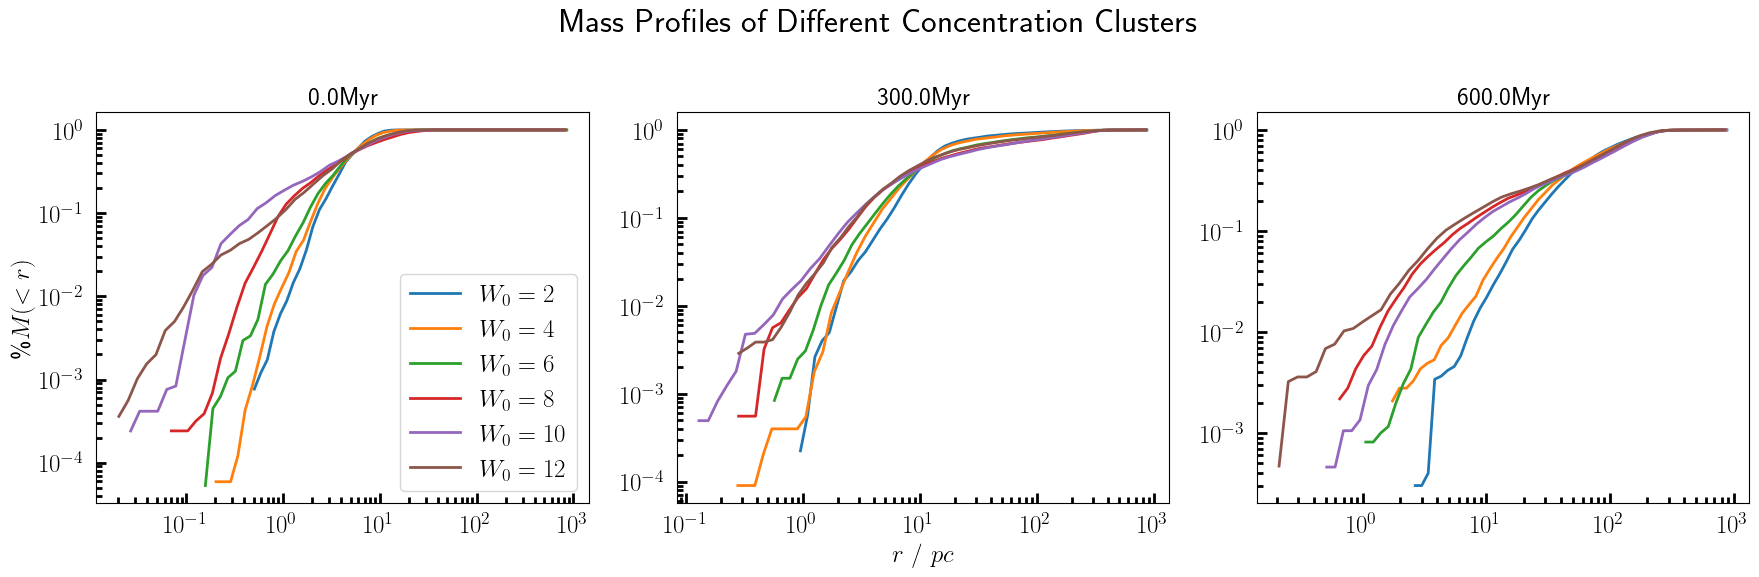

In [113]:
fig, axes = plt.subplots(1, len(times), figsize=(6*len(times),6))

for run, mass_profiles in runs_mass_profiles.items():
    first = True
    for ax, (time, (r_sort, _, m_sums)) in zip(axes, mass_profiles.items()):
        ax.plot(r_sort, m_sums / m_sums[-1],
                label=fr'$W_0={{{run}}}$' if first else '',
               linewidth=2)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f'{time:.1f}Myr')

        first = False



axes[len(times)//2].set_xlabel(r'$r$ / $pc$')
axes[0].set_ylabel(r'\%$M(<r)$')
axes[0].legend()

plt.suptitle('Mass Profiles of Different Concentration Clusters')
plt.tight_layout()
plt.savefig('Images/W_0_mass_profiles.png')
plt.show()

In [114]:
times = [0, 300, 600]
experiment_path = source + '/Mass'

runs_data = get_runs_data(experiment_path, times)

runs_mass_profiles = find_mass_profiles_experiment(runs_data, bins=50, rmax=10**3)


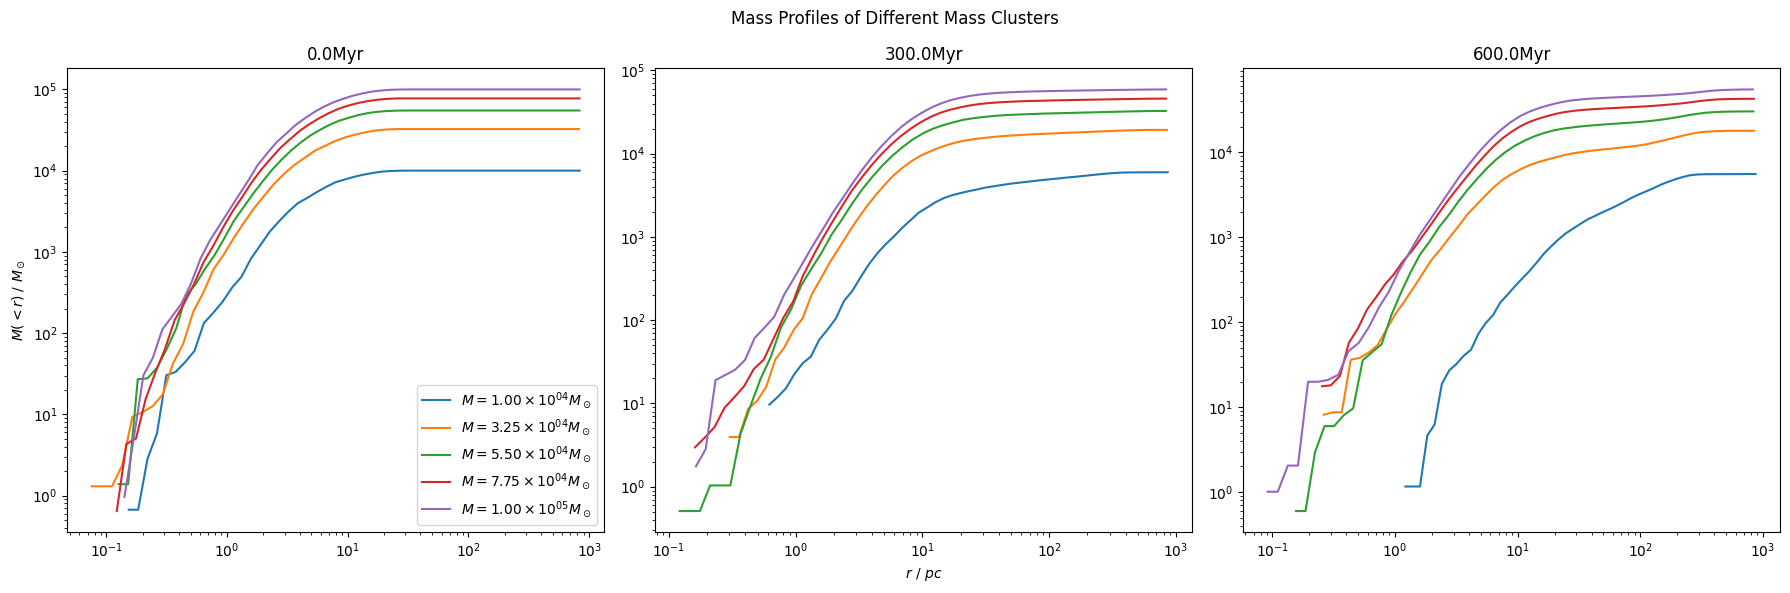

In [144]:
fig, axes = plt.subplots(1, len(times), figsize=(6*len(times),6))

for run, mass_profiles in runs_mass_profiles.items():
    first = True
    for ax, (time, (r_sort, _, m_sums)) in zip(axes, mass_profiles.items()):
        mantissa, exponent = f"{run:.2e}".split("e+")
        
        ax.plot(r_sort, m_sums, 
                label=fr'$M={{{mantissa}}}\times 10^{{{exponent}}} M_\odot$' if first else '',
               linewidth=2)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f'{time:.1f}Myr')

        first = False


axes[len(times)//2].set_xlabel(r'$r$ / $pc$')
axes[0].set_ylabel(r'$M(<r)$ / $M_\odot$')
axes[0].legend()

plt.suptitle('Mass Profiles of Different Mass Clusters')

plt.tight_layout()
plt.savefig('Images/M_mass_profiles.png')
plt.show()

# make a new plot of mass relative to initial mass

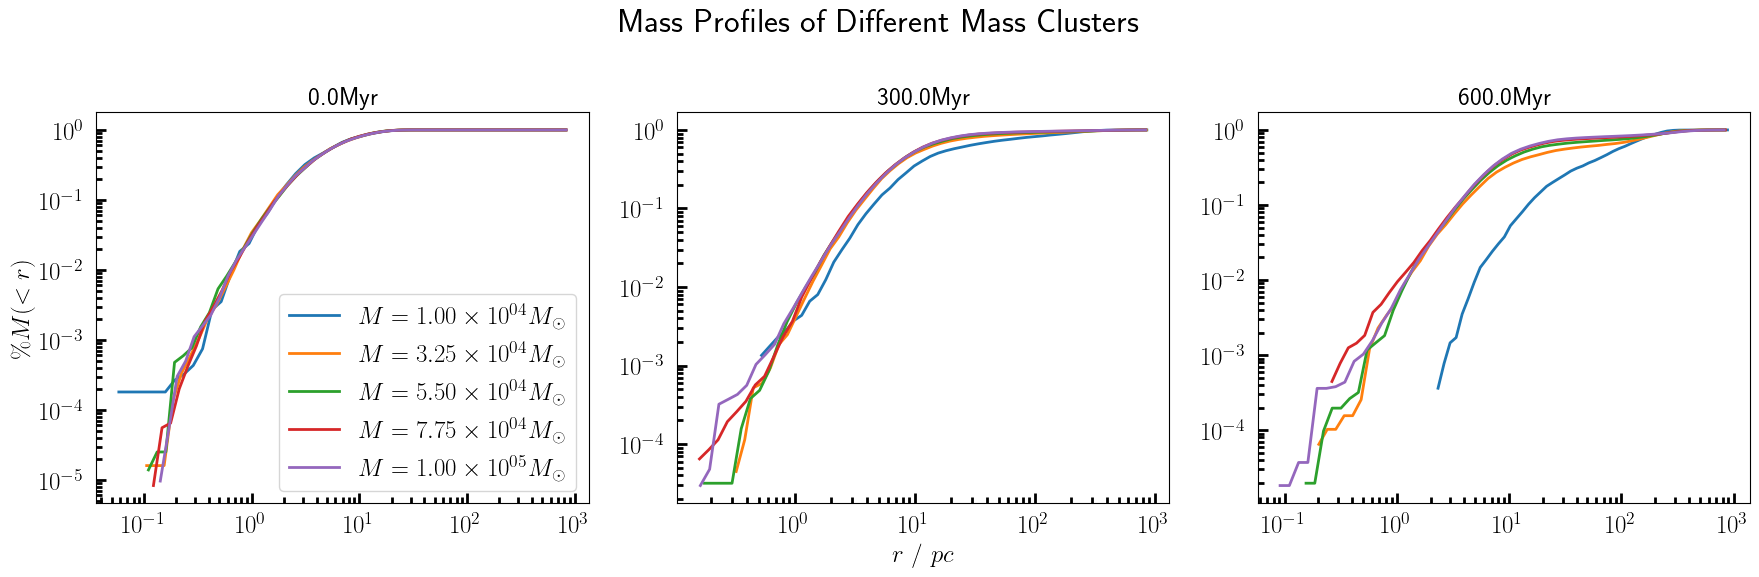

In [115]:
fig, axes = plt.subplots(1, len(times), figsize=(6*len(times),6))

for run, mass_profiles in runs_mass_profiles.items():
    first = True
    for ax, (time, (r_sort, _, m_sums)) in zip(axes, mass_profiles.items()):
        mantissa, exponent = f"{run:.2e}".split("e+")
        
        ax.plot(r_sort, m_sums/ m_sums[-1], 
                label=fr'$M={{{mantissa}}}\times 10^{{{exponent}}} M_\odot$' if first else '',
               linewidth=2)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f'{time:.1f}Myr')

        first = False


axes[len(times)//2].set_xlabel(r'$r$ / $pc$')
axes[0].set_ylabel(r'$\%M(<r)$')
axes[0].legend()

plt.suptitle('Mass Profiles of Different Mass Clusters')

plt.tight_layout()
plt.savefig('Images/M_mass_profiles.png')
plt.show()

In [5]:
times = np.logspace(np.log10(1), np.log10(600), num=10)
experiment_path = source + '/Concentration'

runs_data = get_runs_data(experiment_path, times)

runs_mass_profiles = find_mass_profiles_experiment(runs_data)

/tmp/ipykernel_206179/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206179/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206179/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206179/2808405432.py:27: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_206179/2808405432.py:27: ParserWarning: Length of header or names does not match length o

compute and store

In [5]:
bounding_df_by_experiment = {}

In [6]:
def test():
    fractions = np.asarray([0.9, 0.5, 0.25])
    runs = [2,6,12]
    
    experiment_path = source + '/Concentration'
    
    runs_data_w0 = get_runs_data(experiment_path, runs=runs, step_skip=20)
    
    runs_mass_profiles_w0 = find_mass_profiles_experiment(runs_data_w0)
    
    bounding_df_by_experiment['W_0']  = find_all_bounding_radiis(runs_mass_profiles_w0, fractions)


%lprun -f test -f get_runs_data -f get_steps -f find_mass_profile -f find_all_bounding_radiis -f find_bounding_radii_mp test()

Timer unit: 1e-09 s

Total time: 29.6914 s
File: /tmp/ipykernel_2101919/2307205655.py
Function: test at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def test():
     2         1      12110.0  12110.0      0.0      fractions = np.asarray([0.9, 0.5, 0.25])
     3         1        390.0    390.0      0.0      runs = [2,6,12]
     4                                           
     5         1        530.0    530.0      0.0      experiment_path = source + '/Concentration'
     6                                           
     7         1     1.84e+10 1.84e+10     62.1      runs_data_w0 = get_runs_data(experiment_path, runs=runs, step_skip=20)
     8                                           
     9         1     1.12e+10 1.12e+10     37.9      runs_mass_profiles_w0 = find_mass_profiles_experiment(runs_data_w0)
    10                                           
    11         1    3552157.0 3.55e+06      0.0      boundi

In [151]:
fractions = np.asarray([0.9, 0.5, 0.25])
runs = [2, 6, 12]

experiment_path = source + '/Concentration'

runs_data_w0 = get_runs_data(experiment_path, runs=runs, Myr_skip=5)

runs_mass_profiles_w0 = find_mass_profiles_experiment(runs_data_w0)

bounding_df_by_experiment['W_0']  = find_all_bounding_radiis(runs_mass_profiles_w0, fractions)

In [121]:
store_all_bounding_radiis(source + '/Concentration/bounding_rads.h5', bounding_df_by_experiment['W_0'])

ImportError: `Import pytables` failed.  Use pip or conda to install the pytables package.

In [53]:
find_skip(source + '/Mass/100000', 10)

83

In [7]:
fractions = np.asarray([0.9, 0.5, 0.25])
runs = [10000,55000,100000]

experiment_path = source + '/Mass'

runs_data_m = get_runs_data(experiment_path, runs=runs, Myr_skip=5)

runs_mass_profiles_m = find_mass_profiles_experiment(runs_data_m)

bounding_df_by_experiment['M'] = find_all_bounding_radiis(runs_mass_profiles_m, fractions)

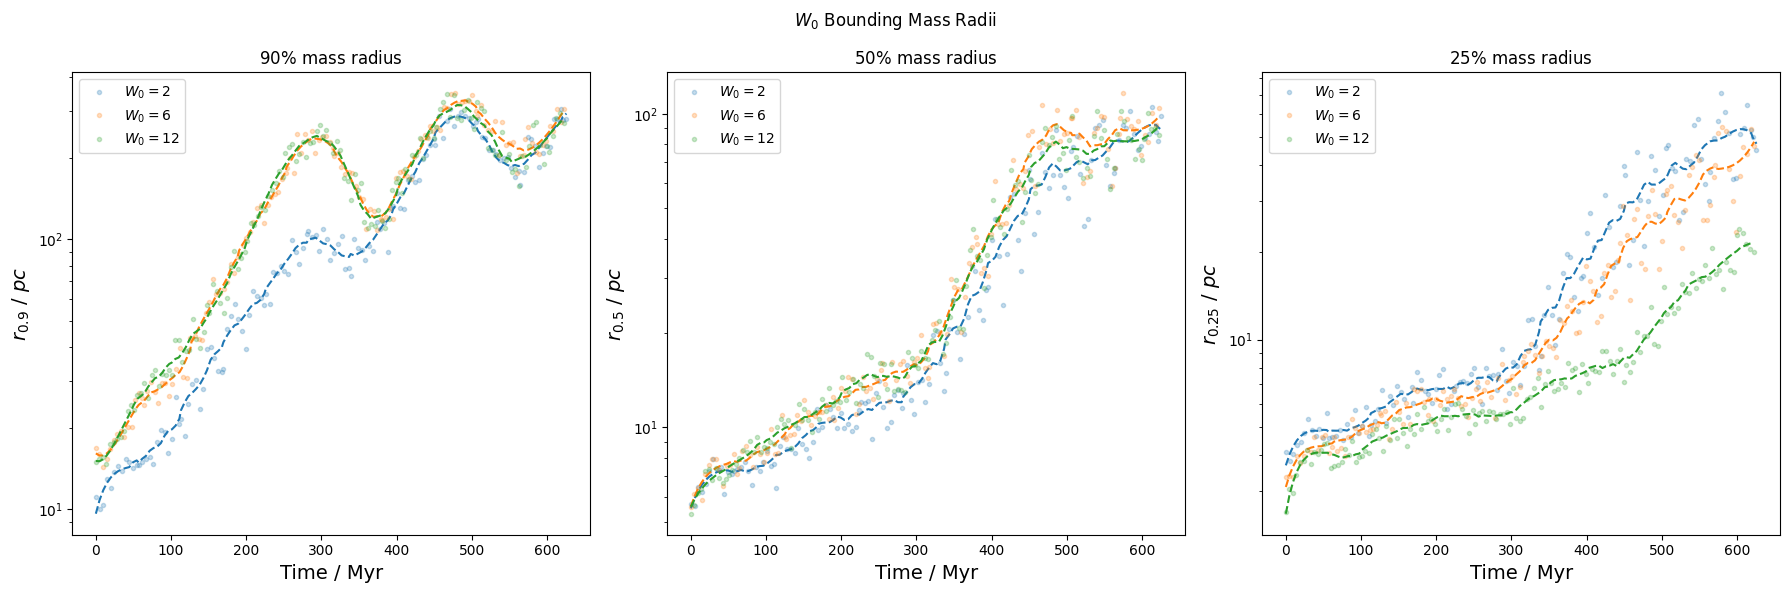

In [165]:
fig, axes = plt.subplots(1, len(fractions), figsize=(6*len(fractions), 6))
run_label = 'W_0'
#median_width = 10 # Myr
savgol_width = 100
runs = [2, 6, 12]

for run, df in bounding_df_by_experiment[run_label].items():
    if run not in runs:
        continue

    #median_window = int(round(median_width / np.median(np.diff(df['time']))))
    savgol_window = int(round(savgol_width / np.median(np.diff(df['time']))))

    
    #radii_clipped = median_filter(df[fractions], size=(median_window, 1))

    radii_smooth = savgol_filter(df[fractions], savgol_window, 3, axis=0)

    for i, frac in enumerate(fractions):
        dataplt, = axes[i].plot(df['time'], df[frac], label=fr'${run_label}={run}$', marker='.', linestyle='', alpha=0.25)
        axes[i].plot(df['time'], radii_smooth[:, i], color=dataplt.get_color(), linestyle='dashed')
        axes[i].set_title(fr'${100*frac:.0f}\%$ mass radius')
        axes[i].set_xlabel('Time / Myr', fontsize=14)
        axes[i].set_ylabel(fr'$r_{{{frac}}}\ /\ pc$', fontsize=14)
        axes[i].legend()
        axes[i].set_yscale('log')

        #axes[i].set_ylim([1,400])

plt.suptitle(fr'${{{run_label}}}$ Bounding Mass Radii')
plt.tight_layout()
plt.savefig(f'Images/{run_label}_mass_radii.png')
plt.show()

### $r_{1/4}$ 
- $W_0$=2 peaks a lot higher than 12
- core collapse happening faster in $W_0$=12
- stays relatively stable until rapidly increasing at ~400Myr

### $r_{1/2}$ 
- relatively consistent accross $W_0$
- high concentration seems to be more sensitive to oscilations

### $r_{9/10}$
- clear oscilations that line up with ~200Myr orbital period
- $W_0$=2 less sensitive to them than higher concentration
- low $W_0$ seems to grow exponentially, compared to a more constant rate at high concentration

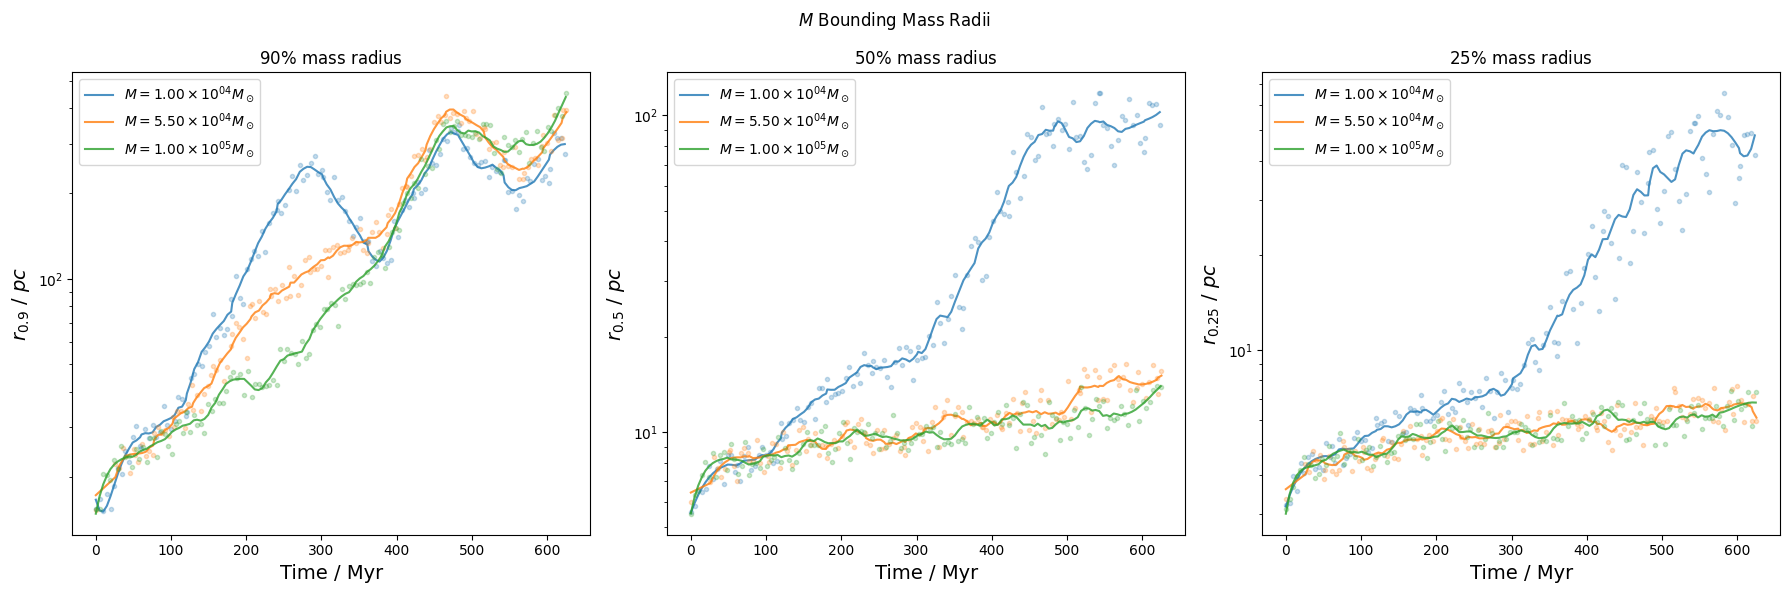

In [164]:
fig, axes = plt.subplots(1, len(fractions), figsize=(6*len(fractions), 6))
run_label = 'M'
#median_width = 10 # Myr
savgol_width = 100
runs = [10000,55000,100000]

for run, df in bounding_df_by_experiment[run_label].items():
    if run not in runs:
        continue

    savgol_window = int(round(savgol_width / np.median(np.diff(df['time']))))

    
    #radii_clipped = median_filter(df[fractions], size=(median_window, 1))

    radii_smooth = savgol_filter(df[fractions], savgol_window, 4, axis=0)

    for i, frac in enumerate(fractions):
        mantissa, exponent = f"{run:.2e}".split("e+")
        
        dataplt, = axes[i].plot(df['time'], df[frac], marker='.', linestyle='', alpha=0.25)
        axes[i].plot(df['time'], radii_smooth[:, i], label=fr'$M={{{mantissa}}}\times 10^{{{exponent}}} M_\odot$',
                     color=dataplt.get_color(), alpha=0.8)
        axes[i].set_title(fr'${100*frac:.0f}\%$ mass radius')
        axes[i].set_xlabel('Time / Myr', fontsize=14)
        axes[i].set_ylabel(fr'$r_{{{frac}}}\ /\ pc$', fontsize=14)
        axes[i].legend()
        axes[i].set_yscale('log')

#axes[0].set_ylim([1,400])

plt.suptitle(fr'${{{run_label}}}$ Bounding Mass Radii')
plt.tight_layout()
plt.savefig(f'Images/{run_label}_mass_radii.png')
plt.show()

# start making captions for final paper. Last line should give you the jist of what the figure is conveying

### $r_{1/4}$ 
- stays almost flat for high M but dissolves for low M
- high M will have a stronger pull so its harder to strip

### $r_{1/2}$ 
- similar to 1/4 but low M has a large singe event disruption instead of a more gradual change which then falls back down
- more tidal shock?
- mass seems to massively influence 1/4 and 1/2 mass evolution, makes sense

### $r_{9/10}$
- struggled to completely remove noise here without completely smoothing out the data
- both follow a similar shape, corrolating with apocentre
- high M expands out further compared to low M

only the higher orbitals seem to be getting stripped in high M compared to an overall expansion in low M

mass seems to have secondarry effect on external stripping compared to tidal effects

In [241]:
r90br50 = {experiment : 
           {run : 
            bounding_df[0.9] / bounding_df[0.5] for run, bounding_df in bounding_df_by_run.items()}
           for experiment, bounding_df_by_run in bounding_df_by_experiment.items()}

(179,)
(201,)
(168,)
(522,)


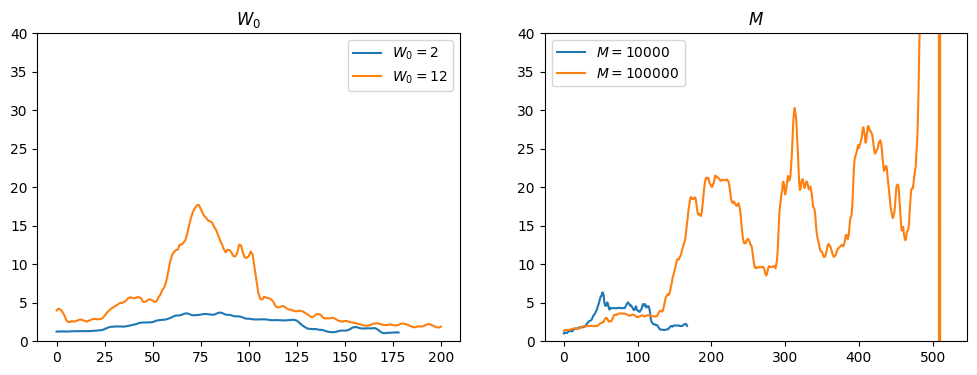

In [243]:
cols = len(r90br50.keys())
fig, axes = plt.subplots(1,cols, figsize=(6*cols, 4))

for (experiment, r90br50_by_run), ax in zip(r90br50.items(), axes):
    for run, ratio in r90br50_by_run.items():    
        print(ratio.shape)
        ratio_clipped = median_filter(ratio, size=50)
    
        ratio_smooth = savgol_filter(ratio_clipped, 10, 4, axis=0)
        
        ax.plot(ratio_smooth, label=fr'${{{experiment}}}={{{run}}}$')

        #ax.set_yscale('log')
        ax.set_ylim([0,40])
        ax.legend()

    ax.set_title(fr'${{{experiment}}}$')
    

/tmp/ipykernel_2721214/3024974260.py:11: RuntimeWarning: divide by zero encountered in divide
  periods = 1/freqs


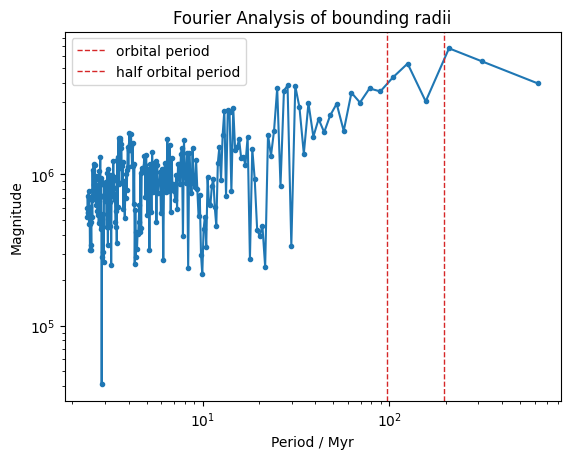

In [315]:
experiment = bounding_df_by_experiment['M'][100000]

dt = np.mean(np.diff(experiment['time']))

signal = experiment[0.9]


fft = np.fft.rfft(signal)

freqs = np.fft.rfftfreq(len(signal), d=dt)
periods = 1/freqs

fig, ax = plt.subplots()
ax.plot(periods, np.abs(fft), marker='.')
ax.set_xlabel("Period / Myr")
ax.set_ylabel("Magnitude")

ax.set_yscale('log')
ax.set_xscale('log')

ax.axvline(195, color='tab:red', linestyle='--', linewidth=1, label='orbital period')
ax.axvline(195/2, color='tab:red', linestyle='--', linewidth=1, label='half orbital period')
ax.set_title("Fourier Analysis of bounding radii")

ax.legend()

plt.show()